# Cow Disease Detection CNN - Training
## Using Real Cows Dataset (3 classes: foot-and-mouth, healthy, lumpy)

Train a CNN model using MobileNetV2 transfer learning on the Cows dataset.
Since the dataset has no Train/Val/Test split, we split it automatically (70/15/15).

In [1]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle
import random

print(f"TensorFlow: {tf.__version__}")
print(f"Keras: {keras.__version__}")
print(f"NumPy: {np.__version__}")

%matplotlib inline

TensorFlow: 2.21.0
Keras: 3.14.1
NumPy: 2.4.1


In [2]:
# ── Configuration ──────────────────────────────────────────────────────
DATASET_PATH  = 'Cows datasets'   # flat class folders live here
SPLIT_PATH    = 'Cows datasets split'  # will hold Train/Val/Test
IMAGE_SIZE    = (224, 224)
BATCH_SIZE    = 16           # smaller batch; dataset is smaller than PlantVillage
TRAIN_RATIO   = 0.70
VAL_RATIO     = 0.15
TEST_RATIO    = 0.15
RANDOM_SEED   = 42

print("=" * 60)
print("LOADING COWS DATASET")
print("=" * 60)

if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATASET_PATH}")

# Detect class folders
cow_classes = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

print(f"\nDataset found at: {DATASET_PATH}")
print(f"Number of classes: {len(cow_classes)}")
print("\nClasses and image counts:")
for cls in cow_classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    imgs = [f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif'))]
    print(f"  {cls:30s} - {len(imgs)} images")

NUM_CLASSES = len(cow_classes)

LOADING COWS DATASET

Dataset found at: Cows datasets
Number of classes: 3

Classes and image counts:
  foot-and-mouth                 - 746 images
  healthy                        - 1291 images
  lumpy                          - 1207 images


In [3]:
# ── Auto-split dataset into Train / Val / Test ─────────────────────────
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}

if os.path.exists(SPLIT_PATH):
    shutil.rmtree(SPLIT_PATH)

for split in ('Train', 'Val', 'Test'):
    for cls in cow_classes:
        os.makedirs(os.path.join(SPLIT_PATH, split, cls), exist_ok=True)

split_summary = {}
for cls in cow_classes:
    src_dir = os.path.join(DATASET_PATH, cls)
    all_imgs = [
        f for f in os.listdir(src_dir)
        if Path(f).suffix.lower() in VALID_EXTS
    ]
    random.shuffle(all_imgs)

    n       = len(all_imgs)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    train_files = all_imgs[:n_train]
    val_files   = all_imgs[n_train:n_train + n_val]
    test_files  = all_imgs[n_train + n_val:]

    for fname in train_files:
        shutil.copy(os.path.join(src_dir, fname),
                    os.path.join(SPLIT_PATH, 'Train', cls, fname))
    for fname in val_files:
        shutil.copy(os.path.join(src_dir, fname),
                    os.path.join(SPLIT_PATH, 'Val', cls, fname))
    for fname in test_files:
        shutil.copy(os.path.join(src_dir, fname),
                    os.path.join(SPLIT_PATH, 'Test', cls, fname))

    split_summary[cls] = {
        'total': n, 'train': len(train_files),
        'val': len(val_files), 'test': len(test_files)
    }

print("\nSplit complete:")
for cls, s in split_summary.items():
    print(f"  {cls:30s}  total={s['total']:4d}  train={s['train']:4d}  val={s['val']:4d}  test={s['test']:4d}")


Split complete:
  foot-and-mouth                  total= 746  train= 522  val= 111  test= 113
  healthy                         total=1291  train= 903  val= 193  test= 195
  lumpy                           total=1207  train= 844  val= 181  test= 182


In [4]:
# ── Data Generators with Augmentation ─────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='reflect',
    channel_shift_range=20.0
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

print("\nLoading training data...")
train_generator = train_datagen.flow_from_directory(
    os.path.join(SPLIT_PATH, 'Train'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print("Loading validation data...")
val_generator = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_PATH, 'Val'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("Loading test data...")
test_generator = val_test_datagen.flow_from_directory(
    os.path.join(SPLIT_PATH, 'Test'),
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✓ Data loaded successfully!")
print(f"  Training samples : {train_generator.samples}")
print(f"  Validation samples: {val_generator.samples}")
print(f"  Test samples     : {test_generator.samples}")

class_indices = train_generator.class_indices
print(f"  Class mapping    : {class_indices}")


Loading training data...
Found 2269 images belonging to 3 classes.
Loading validation data...
Found 485 images belonging to 3 classes.
Loading test data...
Found 490 images belonging to 3 classes.

✓ Data loaded successfully!
  Training samples : 2269
  Validation samples: 485
  Test samples     : 490
  Class mapping    : {'foot-and-mouth': 0, 'healthy': 1, 'lumpy': 2}


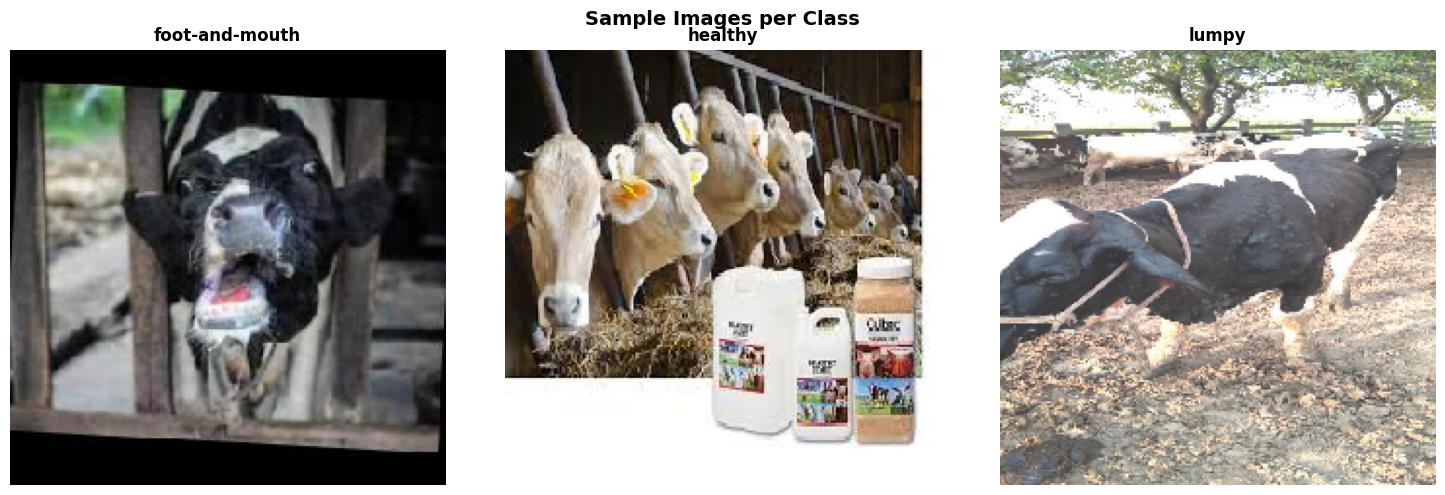

✓ Sample visualisation complete!


In [5]:
# ── Visualise Sample Images ────────────────────────────────────────────
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(5 * NUM_CLASSES, 5))
if NUM_CLASSES == 1:
    axes = [axes]

for ax, cls in zip(axes, cow_classes):
    cls_path = os.path.join(SPLIT_PATH, 'Train', cls)
    img_file = random.choice(os.listdir(cls_path))
    img = load_img(os.path.join(cls_path, img_file), target_size=IMAGE_SIZE)
    ax.imshow(img)
    ax.set_title(cls, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✓ Sample visualisation complete!")

In [6]:
# ── Build Model (MobileNetV2 Transfer Learning) ────────────────────────
print("\n" + "=" * 60)
print("BUILDING CNN MODEL WITH TRANSFER LEARNING")
print("=" * 60)

base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # freeze base initially

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Architecture:")
model.summary()
print("\n✓ Model compiled successfully!")


BUILDING CNN MODEL WITH TRANSFER LEARNING

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,082,051 (11.76 MB)

 Trainable params: 822,275 (3.14 MB)

 Non-trainable params: 2,259,776 (8.62 MB)


✓ Model compiled successfully!


In [7]:
# ── Training ────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("TRAINING MODEL")
print("=" * 60)

os.makedirs('models', exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1,
        min_delta=0.001
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-8,
        verbose=1
    ),
    ModelCheckpoint(
        'models/best_cow_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        save_weights_only=False
    )
]

# --- Phase 1: train only top layers ---
print("\n" + "=" * 60)
print("PHASE 1: Training top layers (Base model frozen)")
print("=" * 60)

history1 = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

# --- Phase 2: fine-tune last 50 layers of base ---
print("\n" + "=" * 60)
print("PHASE 2: Fine-tuning last 50 layers of MobileNetV2")
print("=" * 60)

base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Fine-tuning {trainable_count} layers out of {len(base_model.layers)}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Training completed!")
print("✓ Best model checkpoint saved to: models/best_cow_model.h5")


TRAINING MODEL

PHASE 1: Training top layers (Base model frozen)
Epoch 1/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.6022 - loss: 1.0592
Epoch 1: val_accuracy improved from None to 0.84124, saving model to models/best_cow_model.h5



Epoch 1: finished saving model to models/best_cow_model.h5
142/142 ━━━━━━━━━━━━━━━━━━━━ 97s 644ms/step - accuracy: 0.6703 - loss: 0.8654 - val_accuracy: 0.8412 - val_loss: 0.4490 - learning_rate: 0.0010
Epoch 2/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.7743 - loss: 0.6050
Epoch 2: val_accuracy did not improve from 0.84124
142/142 ━━━━━━━━━━━━━━━━━━━━ 37s 263ms/step - accuracy: 0.7660 - loss: 0.6214 - val_accuracy: 0.8268 - val_loss: 0.4844 - learning_rate: 0.0010
Epoch 3/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.7799 - loss: 0.5447
Epoch 3: val_accuracy improved from 0.84124 to 0.87629, saving model to models/best_cow_model.h5



Epoch 3: finished saving model to models/best_cow_model.h5
142/142 ━━━━━━━━━━━━━━━━━━━━ 37s 260ms/step - accuracy: 0.7779 - loss: 0.5547 - val_accuracy: 0.8763 - val_loss: 0.3118 - learning_rate: 0.0010
Epoch 4/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.7847 - loss: 0.5642
Epoch 4: val_accuracy did not improve from 0.87629
142/142 ━━━━━━━━━━━━━━━━━━━━ 38s 265ms/step - accuracy: 0.7840 - loss: 0.5607 - val_accuracy: 0.8722 - val_loss: 0.3117 - learning_rate: 0.0010
Epoch 5/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.8185 - loss: 0.4508
Epoch 5: val_accuracy did not improve from 0.87629
142/142 ━━━━━━━━━━━━━━━━━━━━ 38s 263ms/step - accuracy: 0.8061 - loss: 0.4849 - val_accuracy: 0.8722 - val_loss: 0.3205 - learning_rate: 0.0010
Epoch 6/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.8000 - loss: 0.4902
Epoch 6: val_accuracy improved from 0.87629 to 0.88866, saving model to models/best_cow_model.h5



Epoch 6: finished saving model to models/best_cow_model.h5
142/142 ━━━━━━━━━━━━━━━━━━━━ 37s 260ms/step - accuracy: 0.7995 - loss: 0.4979 - val_accuracy: 0.8887 - val_loss: 0.3079 - learning_rate: 0.0010
Epoch 7/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.8245 - loss: 0.4517
Epoch 7: val_accuracy improved from 0.88866 to 0.89072, saving model to models/best_cow_model.h5



Epoch 7: finished saving model to models/best_cow_model.h5
142/142 ━━━━━━━━━━━━━━━━━━━━ 39s 273ms/step - accuracy: 0.8136 - loss: 0.4559 - val_accuracy: 0.8907 - val_loss: 0.2957 - learning_rate: 0.0010
Epoch 8/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.8114 - loss: 0.4378
Epoch 8: val_accuracy did not improve from 0.89072
142/142 ━━━━━━━━━━━━━━━━━━━━ 37s 261ms/step - accuracy: 0.8224 - loss: 0.4272 - val_accuracy: 0.8825 - val_loss: 0.2907 - learning_rate: 0.0010
Epoch 9/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.8129 - loss: 0.4457
Epoch 9: val_accuracy improved from 0.89072 to 0.90515, saving model to models/best_cow_model.h5


...


Epoch 10: finished saving model to models/best_cow_model.h5
142/142 ━━━━━━━━━━━━━━━━━━━━ 53s 373ms/step - accuracy: 0.8806 - loss: 0.3086 - val_accuracy: 0.9258 - val_loss: 0.2124 - learning_rate: 1.2500e-05
Epoch 11/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.8794 - loss: 0.3117
Epoch 11: val_accuracy did not improve from 0.92577
142/142 ━━━━━━━━━━━━━━━━━━━━ 77s 336ms/step - accuracy: 0.8832 - loss: 0.3075 - val_accuracy: 0.9237 - val_loss: 0.2093 - learning_rate: 1.2500e-05
Epoch 12/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.8944 - loss: 0.2784
Epoch 12: val_accuracy improved from 0.92577 to 0.92990, saving model to models/best_cow_model.h5



Epoch 12: finished saving model to models/best_cow_model.h5
142/142 ━━━━━━━━━━━━━━━━━━━━ 47s 329ms/step - accuracy: 0.8938 - loss: 0.2815 - val_accuracy: 0.9299 - val_loss: 0.2038 - learning_rate: 1.2500e-05
Epoch 13/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - accuracy: 0.8852 - loss: 0.3225
Epoch 13: val_accuracy did not improve from 0.92990
142/142 ━━━━━━━━━━━━━━━━━━━━ 46s 324ms/step - accuracy: 0.8872 - loss: 0.2975 - val_accuracy: 0.9237 - val_loss: 0.2049 - learning_rate: 1.2500e-05
Epoch 14/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.8972 - loss: 0.2780
Epoch 14: val_accuracy improved from 0.92990 to 0.93196, saving model to models/best_cow_model.h5



Epoch 14: finished saving model to models/best_cow_model.h5
142/142 ━━━━━━━━━━━━━━━━━━━━ 47s 330ms/step - accuracy: 0.8986 - loss: 0.2764 - val_accuracy: 0.9320 - val_loss: 0.2027 - learning_rate: 1.2500e-05
Epoch 15/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step - accuracy: 0.8807 - loss: 0.3064
Epoch 15: val_accuracy improved from 0.93196 to 0.93608, saving model to models/best_cow_model.h5



Epoch 15: finished saving model to models/best_cow_model.h5
142/142 ━━━━━━━━━━━━━━━━━━━━ 49s 346ms/step - accuracy: 0.8845 - loss: 0.2901 - val_accuracy: 0.9361 - val_loss: 0.1931 - learning_rate: 1.2500e-05
Epoch 16/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.8974 - loss: 0.2760
Epoch 16: val_accuracy did not improve from 0.93608
142/142 ━━━━━━━━━━━━━━━━━━━━ 47s 333ms/step - accuracy: 0.8995 - loss: 0.2736 - val_accuracy: 0.9361 - val_loss: 0.1938 - learning_rate: 1.2500e-05
Epoch 17/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.8999 - loss: 0.2705
Epoch 17: val_accuracy improved from 0.93608 to 0.93814, saving model to models/best_cow_model.h5



Epoch 17: finished saving model to models/best_cow_model.h5
142/142 ━━━━━━━━━━━━━━━━━━━━ 47s 333ms/step - accuracy: 0.8947 - loss: 0.2793 - val_accuracy: 0.9381 - val_loss: 0.1905 - learning_rate: 1.2500e-05
Epoch 18/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.9051 - loss: 0.2598
Epoch 18: val_accuracy did not improve from 0.93814
142/142 ━━━━━━━━━━━━━━━━━━━━ 48s 334ms/step - accuracy: 0.8995 - loss: 0.2746 - val_accuracy: 0.9340 - val_loss: 0.1999 - learning_rate: 1.2500e-05
Epoch 19/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.8851 - loss: 0.2785
Epoch 19: val_accuracy did not improve from 0.93814
142/142 ━━━━━━━━━━━━━━━━━━━━ 51s 354ms/step - accuracy: 0.8925 - loss: 0.2759 - val_accuracy: 0.9299 - val_loss: 0.1997 - learning_rate: 1.2500e-05
Epoch 20/20
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.9083 - loss: 0.2727
Epoch 20: val_accuracy did not improve from 0.93814
142/142 ━━━━━━━━━━━━━━━━━━━━ 56s 392ms/step - accuracy: 0.8973 - loss: 0

In [8]:
# ── Evaluate on Test Set ────────────────────────────────────────────────
print("\n" + "=" * 60)
print("EVALUATING ON TEST SET")
print("=" * 60)

test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

# Predictions
test_generator.reset()
y_pred_prob = model.predict(test_generator, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = test_generator.classes

# Map index -> class name
idx_to_class = {v: k for k, v in class_indices.items()}

print("\nClassification Report:")
print(classification_report(
    y_true, y_pred,
    target_names=[idx_to_class[i] for i in range(NUM_CLASSES)]
))

cm = confusion_matrix(y_true, y_pred)


EVALUATING ON TEST SET
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 230ms/step - accuracy: 0.9327 - loss: 0.1771

Test Loss    : 0.1771
Test Accuracy: 93.27%
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 265ms/step

Classification Report:
                precision    recall  f1-score   support

foot-and-mouth       0.97      0.99      0.98       113
       healthy       0.90      0.95      0.92       195
         lumpy       0.95      0.88      0.91       182

      accuracy                           0.93       490
     macro avg       0.94      0.94      0.94       490
  weighted avg       0.93      0.93      0.93       490



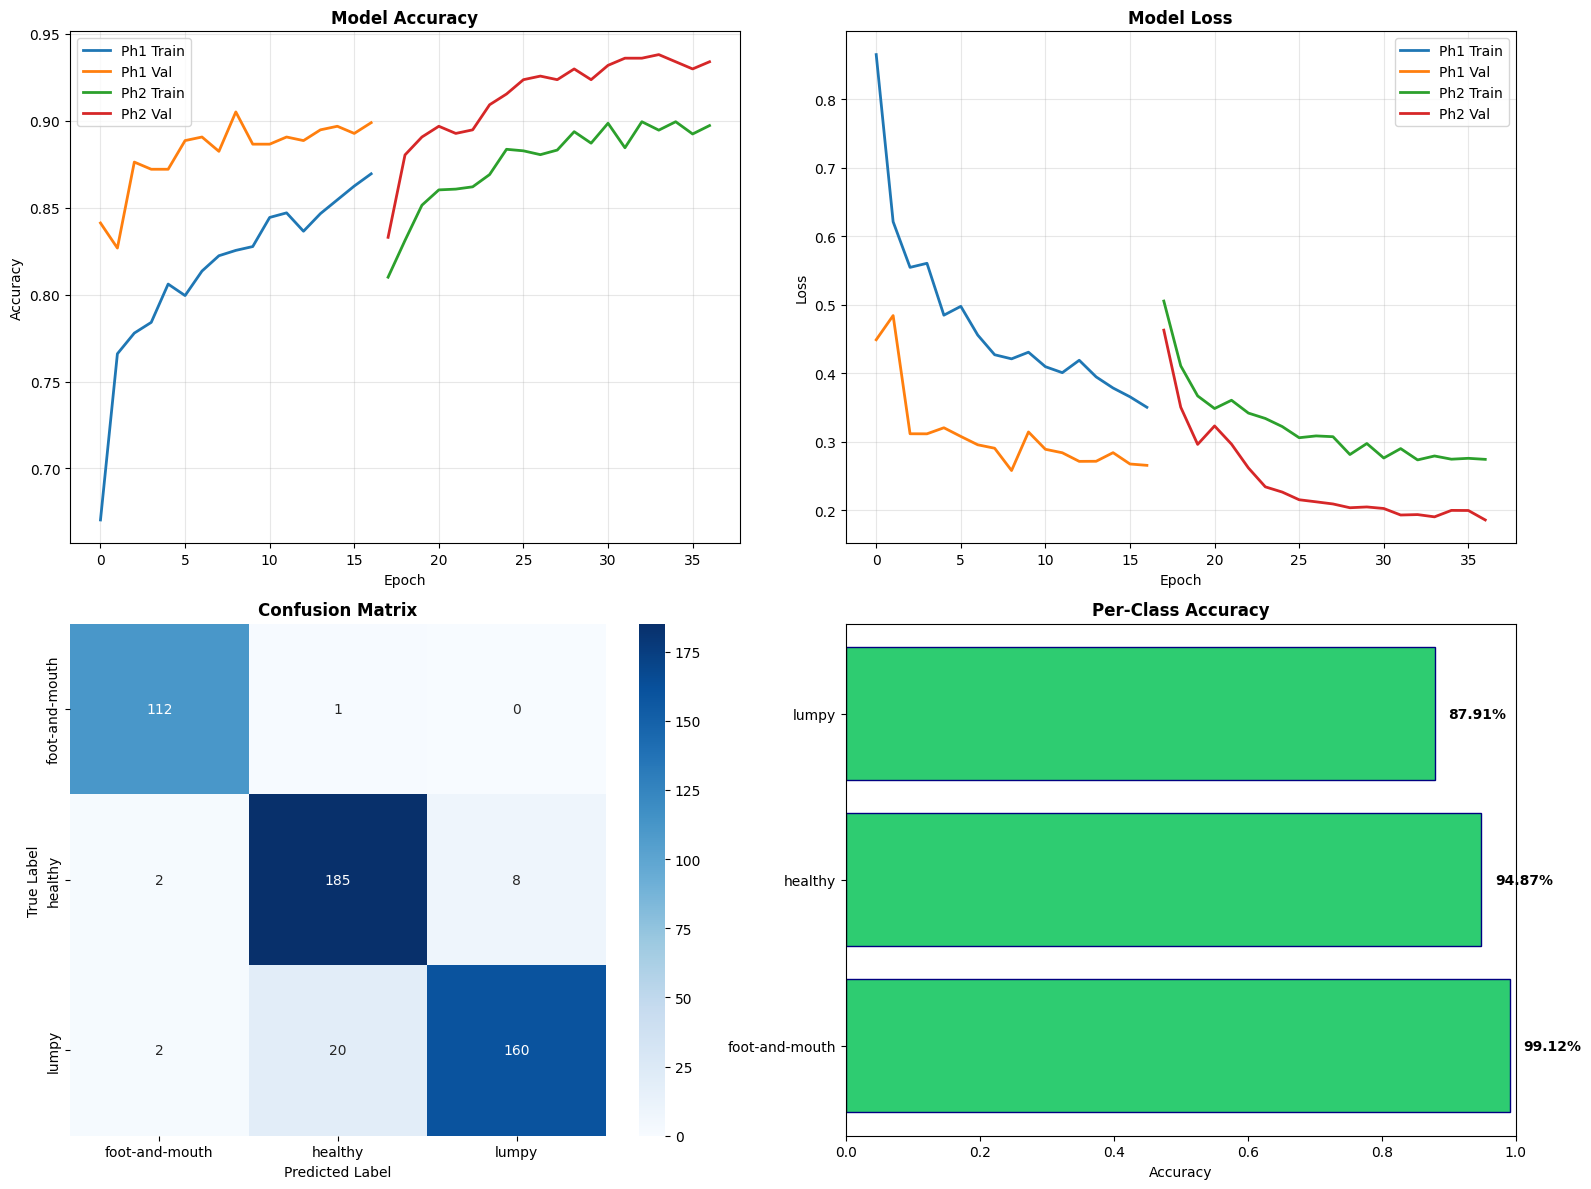

✓ Visualisation complete!


In [9]:
# ── Visualise Results ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) Accuracy
axes[0, 0].plot(history1.history['accuracy'],     label='Ph1 Train', linewidth=2)
axes[0, 0].plot(history1.history['val_accuracy'], label='Ph1 Val',   linewidth=2)
offset = len(history1.history['accuracy'])
axes[0, 0].plot(
    [offset + i for i in range(len(history2.history['accuracy']))],
    history2.history['accuracy'], label='Ph2 Train', linewidth=2)
axes[0, 0].plot(
    [offset + i for i in range(len(history2.history['val_accuracy']))],
    history2.history['val_accuracy'], label='Ph2 Val', linewidth=2)
axes[0, 0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2) Loss
axes[0, 1].plot(history1.history['loss'],     label='Ph1 Train', linewidth=2)
axes[0, 1].plot(history1.history['val_loss'], label='Ph1 Val',   linewidth=2)
axes[0, 1].plot(
    [offset + i for i in range(len(history2.history['loss']))],
    history2.history['loss'], label='Ph2 Train', linewidth=2)
axes[0, 1].plot(
    [offset + i for i in range(len(history2.history['val_loss']))],
    history2.history['val_loss'], label='Ph2 Val', linewidth=2)
axes[0, 1].set_title('Model Loss', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3) Confusion Matrix
class_labels = [idx_to_class[i] for i in range(NUM_CLASSES)]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=class_labels, yticklabels=class_labels)
axes[1, 0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('True Label')
axes[1, 0].set_xlabel('Predicted Label')

# 4) Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
colors = ['#2ecc71' if a >= 0.8 else '#e74c3c' for a in per_class_acc]
axes[1, 1].barh(range(NUM_CLASSES), per_class_acc, color=colors, edgecolor='navy')
axes[1, 1].set_yticks(range(NUM_CLASSES))
axes[1, 1].set_yticklabels(class_labels, fontsize=10)
axes[1, 1].set_xlabel('Accuracy')
axes[1, 1].set_title('Per-Class Accuracy', fontsize=12, fontweight='bold')
axes[1, 1].set_xlim([0, 1])
for i, v in enumerate(per_class_acc):
    axes[1, 1].text(v + 0.02, i, f'{v:.2%}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("✓ Visualisation complete!")

In [ ]:
# ── Save Model & Metadata ─────────────────────────────────────────────
import json

print("\n" + "=" * 60)
print("SAVING MODEL")
print("=" * 60)

model.save('models/cow_disease_model.h5')
model.save('models/cow_disease_model_full/')

with open('models/cow_classes.pkl', 'wb') as f:
    pickle.dump(cow_classes, f)

with open('models/cow_class_indices.pkl', 'wb') as f:
    pickle.dump(class_indices, f)

model_info = {
    'model_name'  : 'Cow Disease Detection',
    'num_classes' : NUM_CLASSES,
    'classes'     : cow_classes,
    'class_indices': class_indices,
    'test_accuracy': float(test_accuracy),
    'test_loss'   : float(test_loss),
    'image_size'  : list(IMAGE_SIZE),
    'architecture': 'MobileNetV2 with Transfer Learning'
}

with open('models/cow_model_info.json', 'w') as f:
    json.dump(model_info, f, indent=4)

print("\n✓ Model saved successfully!")
print("\nSaved files:")
print("  - models/cow_disease_model.h5        (Keras H5 format)")
print("  - models/cow_disease_model_full/     (SavedModel format)")
print("  - models/cow_classes.pkl             (Class names list)")
print("  - models/cow_class_indices.pkl       (Class indices mapping)")
print("  - models/cow_model_info.json         (Model metadata)")
print("  - models/best_cow_model.h5           (Best checkpoint)")
print(f"\n" + "=" * 60)
print(f"TRAINING COMPLETE")
print(f"=" * 60)
print(f"Test Accuracy   : {test_accuracy*100:.2f}%")
print(f"Number of Classes: {NUM_CLASSES}")
print(f"Model Parameters : {model.count_params():,}")
print(f"=" * 60)


SAVING MODEL


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=models/cow_disease_model_full/.

: 

In [ ]:
# ── Predict on Sample Test Images ─────────────────────────────────────
def predict_cow_disease(image_path, model, class_names):
    """Predict disease class for a single image."""
    img = load_img(image_path, target_size=IMAGE_SIZE)
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction  = model.predict(img_array, verbose=0)
    confidence  = float(np.max(prediction))
    pred_idx    = int(np.argmax(prediction))
    pred_class  = class_names[pred_idx]

    top3_indices = np.argsort(prediction[0])[::-1][:3]
    top3 = [
        {'class': class_names[i], 'confidence': f"{prediction[0][i]*100:.2f}%"}
        for i in top3_indices
    ]
    return {'predicted_class': pred_class, 'confidence': f"{confidence*100:.2f}%", 'top3': top3}

print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

test_base = os.path.join(SPLIT_PATH, 'Test')
for cls in cow_classes:
    cls_test_dir = os.path.join(test_base, cls)
    imgs = os.listdir(cls_test_dir)
    if imgs:
        result = predict_cow_disease(
            os.path.join(cls_test_dir, imgs[0]), model, cow_classes
        )
        print(f"\nTrue class : {cls}")
        print(f"  Predicted: {result['predicted_class']}")
        print(f"  Confidence: {result['confidence']}")
        print(f"  Top 3:")
        for p in result['top3']:
            print(f"    - {p['class']}: {p['confidence']}")

print("\n✓ Sample predictions complete!")